In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### Load Data

In [49]:
df = pd.read_csv('ai_impact.csv')
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
df.head()

,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,Exercise_Hours_Per_Week,Exercise_Level,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
0,1,56,56-65,Female,No,22.2,Normal,Fitness Tracker,8,Medium,9,Active,17,68,69,1,1.47,Improved,0.11,9,High,Low
1,2,69,66-79,Male,No,24.8,Normal,Fitness Tracker,8,Medium,11,Active,19,51,63,12,23.53,Highly Improved,1.33,7,Medium,Low
2,3,46,46-55,Female,No,23.1,Normal,Mental Health App,8,Medium,4,Moderate,12,57,72,15,26.32,Highly Improved,1.67,5,Medium,Low
3,4,32,26-35,Female,Yes,24.9,Normal,Fitness Tracker,16,High,1,Sedentary,17,83,99,16,19.28,Highly Improved,0.94,1,Low,Medium
4,5,60,56-65,Male,No,30.4,Obese,Fitness Tracker,11,Medium,1,Sedentary,12,41,39,-2,-4.88,Declined,-0.17,9,High,Medium


#### Show five last rows

In [50]:
df.tail()

,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,Exercise_Hours_Per_Week,Exercise_Level,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
4995,4996,42,36-45,Female,Yes,20.0,Normal,Fitness Tracker,19,High,0,Sedentary,19,57,58,1,1.75,Improved,0.05,10,High,Medium
4996,4997,39,36-45,Female,Yes,22.7,Normal,Diagnostic Assistant,16,High,4,Moderate,20,52,57,5,9.62,Improved,0.29,5,Medium,Medium
4997,4998,48,46-55,Female,No,26.8,Overweight,Mental Health App,13,Medium,12,Active,25,61,71,10,16.39,Improved,0.71,3,Low,Low
4998,4999,34,26-35,Female,Yes,27.9,Overweight,Telemedicine,13,Medium,2,Sedentary,15,53,72,19,35.85,Highly Improved,1.36,2,Low,Medium
4999,5000,72,66-79,Male,No,22.0,Normal,Diagnostic Assistant,2,Low,4,Moderate,6,50,56,6,12.00,Improved,2.00,6,Medium,Low


#### shape of dataset

In [51]:
df.shape

(5000, 22)

#### Check if there is duplicates/repeating rows in dataset

In [52]:
df.duplicated().sum()

np.int64(0)

###### int64(0) means that there is 0 duplicates hence there is no duplicated rows in our dataset

#### Check if there is null/Not Available Value in dataset

In [53]:
df.isnull().sum().to_frame(name='Null Count')

,Null Count
Participant_ID,0
Age,0
Age_Group,0
Gender,0
Chronic_Condition,0
BMI,0
BMI_Category,0
AI_Tool_Type,0
AI_Health_App_Usage_Hours_Per_Week,0
AI_Usage_Level,0


#### Show information of dataset for Numeric and categorical columns

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Participant_ID                      5000 non-null   int64  
 1   Age                                 5000 non-null   int64  
 2   Age_Group                           5000 non-null   str    
 3   Gender                              5000 non-null   str    
 4   Chronic_Condition                   5000 non-null   str    
 5   BMI                                 5000 non-null   float64
 6   BMI_Category                        5000 non-null   str    
 7   AI_Tool_Type                        5000 non-null   str    
 8   AI_Health_App_Usage_Hours_Per_Week  5000 non-null   int64  
 9   AI_Usage_Level                      5000 non-null   str    
 10  Exercise_Hours_Per_Week             5000 non-null   int64  
 11  Exercise_Level                      5000 non-null   st

#### To show unique counts of items in each columns

In [55]:
df.nunique().to_frame(name='unique counts')

,unique counts
Participant_ID,5000
Age,62
Age_Group,6
Gender,3
Chronic_Condition,2
BMI,238
BMI_Category,4
AI_Tool_Type,4
AI_Health_App_Usage_Hours_Per_Week,21
AI_Usage_Level,3


#### Show Numeric Stastics of Dataset

In [56]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Participant_ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.50,3750.25,5000.0
Age,5000.0,48.805600,17.906991,18.0,34.00,49.00,64.00,79.0
BMI,5000.0,25.017560,3.980900,10.6,22.40,25.05,27.70,38.6
AI_Health_App_Usage_Hours_Per_Week,5000.0,10.235600,6.016389,0.0,5.00,10.50,15.00,20.0
Exercise_Hours_Per_Week,5000.0,7.047000,4.299033,0.0,3.00,7.00,11.00,14.0
Total_Engagement_Hours_Per_Week,5000.0,17.282600,7.424673,0.0,12.00,17.00,23.00,34.0
Health_Score_Before_AI,5000.0,64.432200,14.563015,40.0,52.00,64.00,77.00,89.0
Health_Score_After_AI,5000.0,71.734000,16.016446,35.0,59.00,72.00,84.00,100.0
Improvement,5000.0,7.301800,7.358230,-5.0,1.00,7.00,13.00,20.0
Improvement_Percentage,5000.0,12.097002,13.010823,-12.5,1.45,11.41,21.28,50.0


#### Create variable for numerical and categorical columns

In [57]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

#### To check outliers in dataset(By Using IQR)

In [58]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR =  Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)).sum().to_frame(name='outliers')

,outliers
Participant_ID,0
Age,0
BMI,43
AI_Health_App_Usage_Hours_Per_Week,0
Exercise_Hours_Per_Week,0
Total_Engagement_Hours_Per_Week,0
Health_Score_Before_AI,0
Health_Score_After_AI,0
Improvement,0
Improvement_Percentage,0


#### This boxplot show outliers 

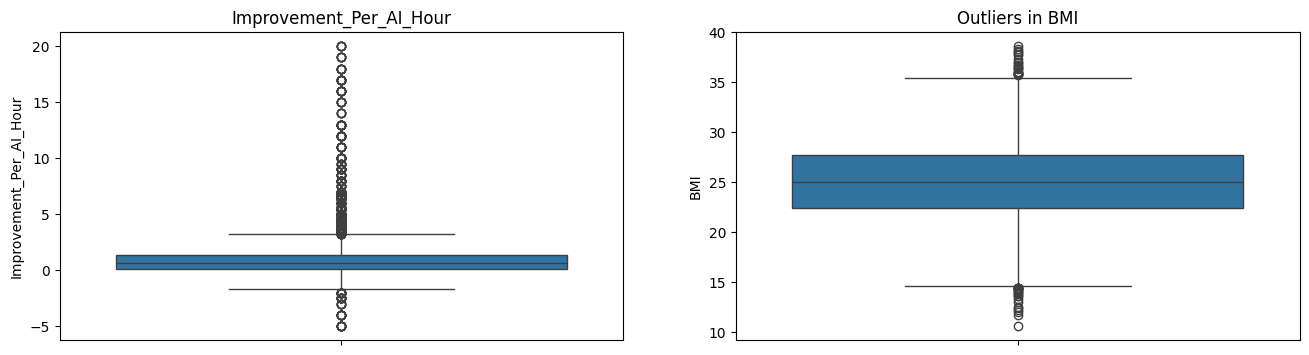

In [59]:
fig, ax =plt.subplots(1,2, figsize=(16,4))

sns.boxplot(df['Improvement_Per_AI_Hour'], ax=ax[0])
ax[0].set_title('Improvement_Per_AI_Hour')

sns.boxplot(df['BMI'], ax=ax[1])
ax[1].set_title('Outliers in BMI')

plt.show()

#### To show correlation_matrix between pair of features

In [60]:
corr = df[num_cols].corr()
print(corr)

                                    Participant_ID       Age       BMI  AI_Health_App_Usage_Hours_Per_Week  Exercise_Hours_Per_Week  Total_Engagement_Hours_Per_Week  Health_Score_Before_AI  Health_Score_After_AI  Improvement  Improvement_Percentage  Improvement_Per_AI_Hour  Satisfaction_Score
Participant_ID                            1.000000 -0.012667 -0.008850                            0.025026                -0.013811                         0.012282                0.024770               0.023553     0.002244               -0.005348                -0.010541           -0.015721
Age                                      -0.012667  1.000000  0.025317                            0.019221                 0.026481                         0.030908                0.026113               0.022350    -0.003033               -0.005363                 0.001937           -0.015139
BMI                                      -0.008850  0.025317  1.000000                            0.028288            

### EXPLORATORY DATA ANALYSIS(EDA)

#### 1.Age Distribution

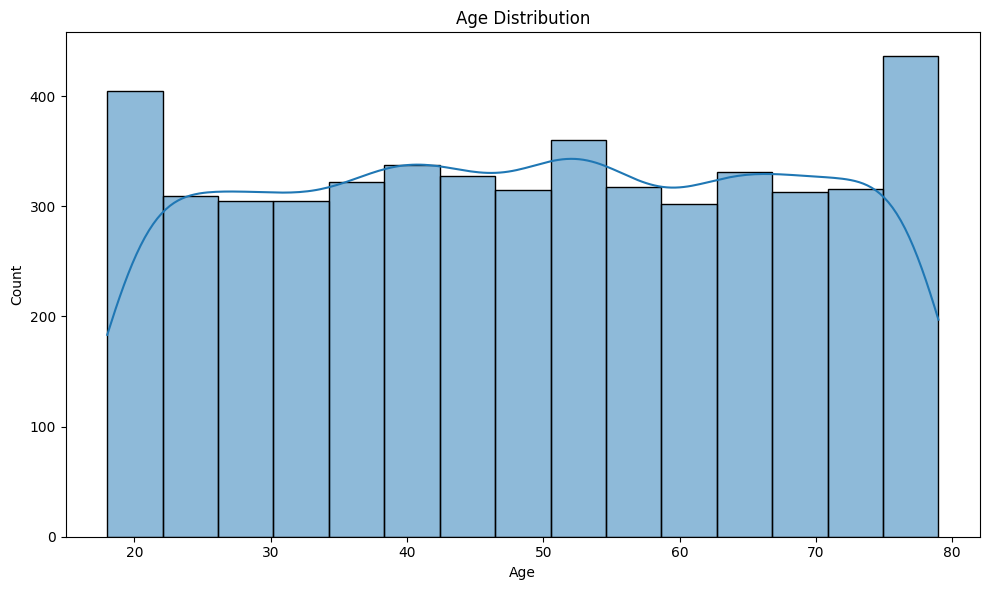

In [62]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x = 'Age', bins=15, binrange=(18,79), kde=True, edgecolor='black')
plt.title('Age Distribution')
plt.tight_layout()
plt.show()

***insight**.
The histogram shows the distribution of participants' Ages, while the KDE curve provides a smoothed estimate of the distribution.The ages are spread across a wide range with no dominant age group, suggesting relatively balanced sample

#### 2.Gender counts

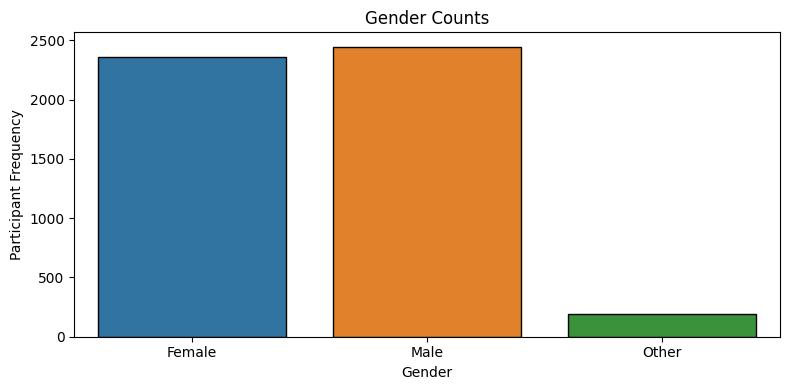

In [63]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Gender', edgecolor='black', palette='tab10')
plt.title('Gender Counts')
plt.ylabel('Participant Frequency')
plt.tight_layout()
plt.show()

#### 3.Chronic_Condition Distribution

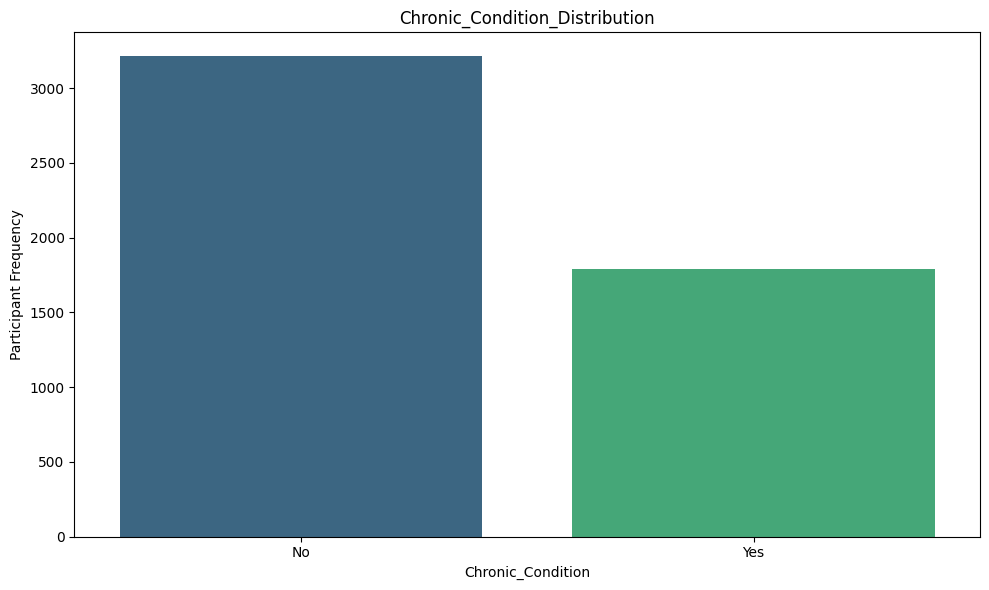

In [64]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Chronic_Condition', palette='viridis')
plt.title('Chronic_Condition_Distribution')
plt.ylabel('Participant Frequency')
plt.tight_layout()
plt.show()


The countplot show that individuals without chronic diseases are more than those with chronic diseases.Specifically, there are over 3000 individuals without chronic condition, While approximately 1800 indivduals are affected.this indicate dataset is imbalanced...

#### 4.BMI vs BMI_Category

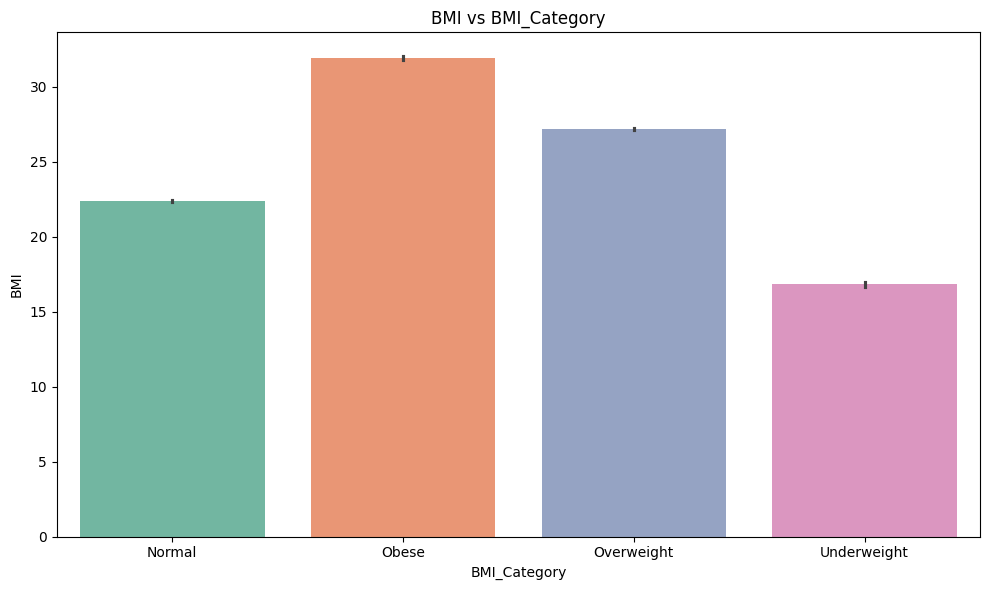

In [65]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='BMI_Category', y='BMI', palette='Set2')
plt.title('BMI vs BMI_Category')
plt.tight_layout()
plt.show()

#### 5. Participant_Count by Age_Group

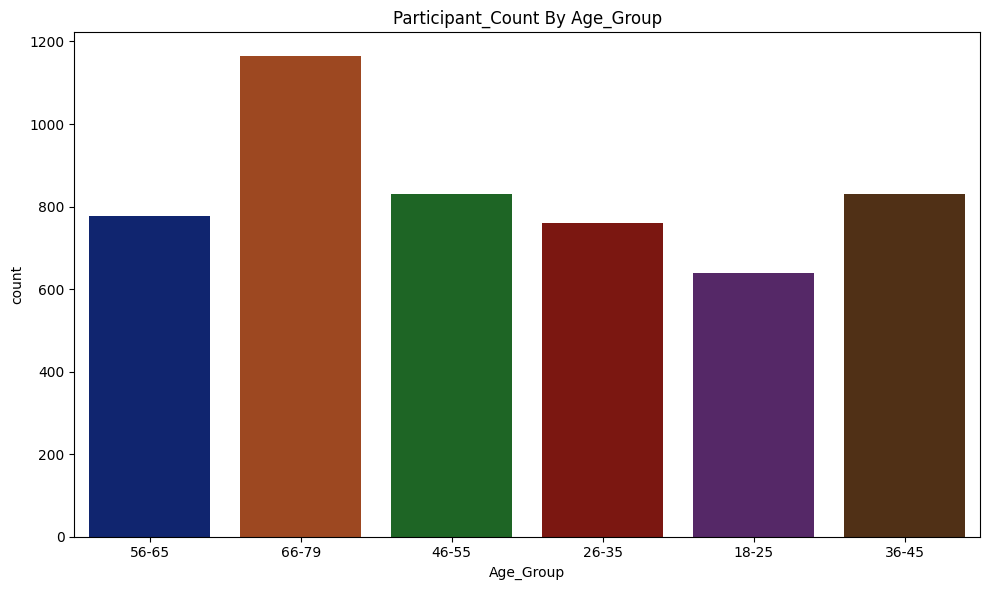

In [66]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Age_Group', palette='dark')
plt.title('Participant_Count By Age_Group')
plt.tight_layout()
plt.show()

##### 6. AI_app_usage vs Exercise(Hours)

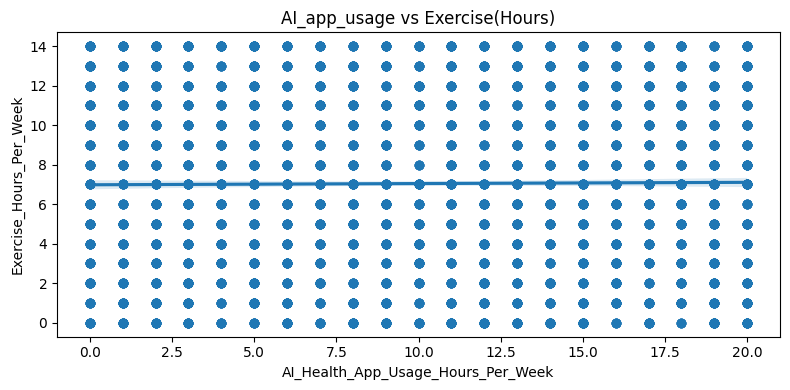

In [67]:
plt.figure(figsize=(8,4))
sns.regplot(x='AI_Health_App_Usage_Hours_Per_Week', y='Exercise_Hours_Per_Week' ,data=df)
plt.title('AI_app_usage vs Exercise(Hours)')
plt.tight_layout()
plt.show()

To identify which specif AI tool type is utilized for the highest number of hours per week by patients

#### 7. AI_app_Usage vs AI_tool

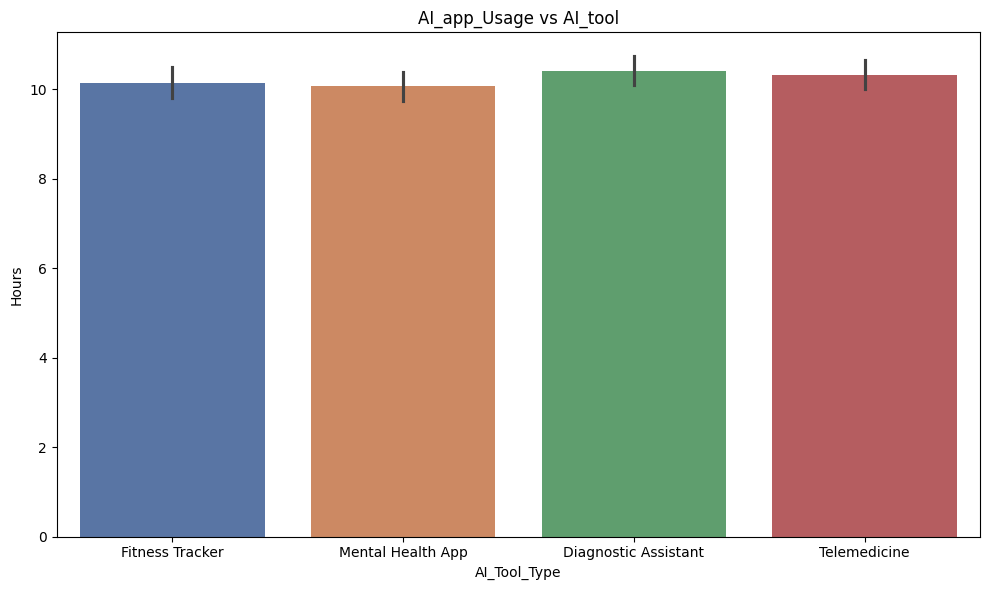

In [68]:
plt.figure(figsize=(10,6))
sns.barplot(df, y=df['AI_Health_App_Usage_Hours_Per_Week'], x=df['AI_Tool_Type'], palette='deep')
plt.title('AI_app_Usage vs AI_tool')
plt.ylabel('Hours')
plt.tight_layout()
plt.show()

#### 8. Exercise_per_week vs Chronic_Condition
Do patients with chronic condition engage in fewer hours of exercise per week compared to those without??

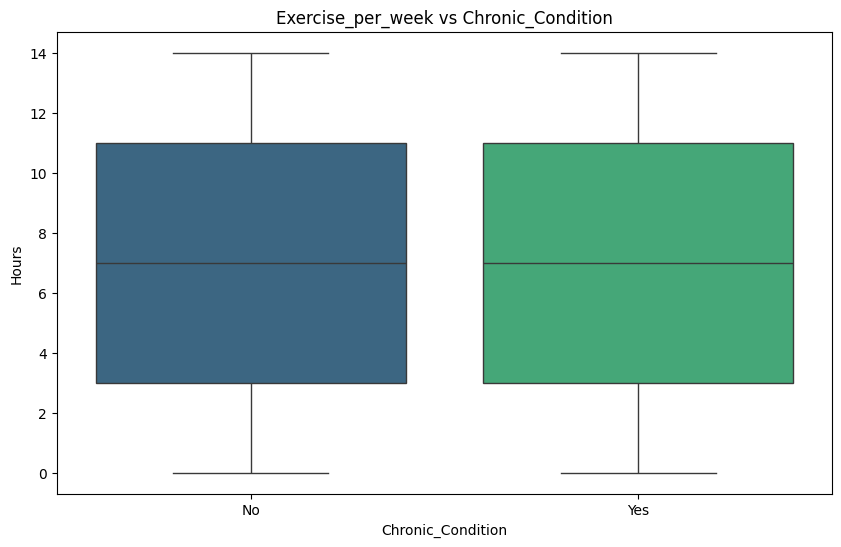

In [69]:
plt.figure(figsize=(10,6))
sns.boxplot(df, x=df['Chronic_Condition'], y=df['Exercise_Hours_Per_Week'], palette='viridis')
plt.title('Exercise_per_week vs Chronic_Condition')
plt.ylabel('Hours')
plt.show()

The boxplot visualize that patients with long term illiness can perform their body exercise(in Hours) as to those without chronic diseases.It means that chronic condition is not a reason for patients to unable perform their exercise

#### 9. Age vs Total_Engagement by Gender


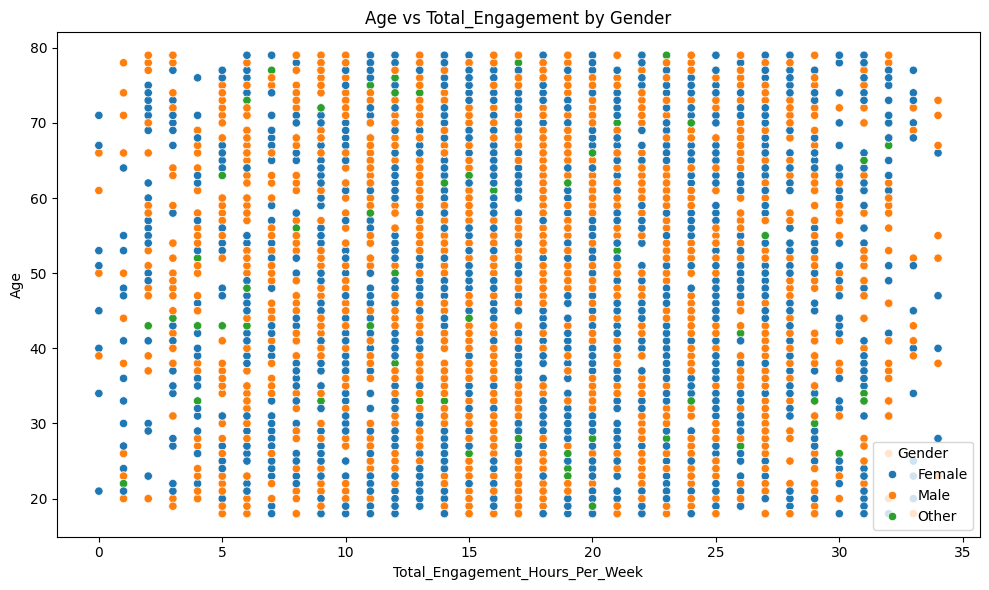

In [70]:
plt.figure(figsize=(10,6))
sns.scatterplot(df, y=df['Age'], x=df['Total_Engagement_Hours_Per_Week'], hue=df['Gender'])
plt.title('Age vs Total_Engagement by Gender')
plt.tight_layout()
plt.show()

#### 10. Health_Before_AI vs Health_After_AI

to show how health condition are related to AI in our dataset

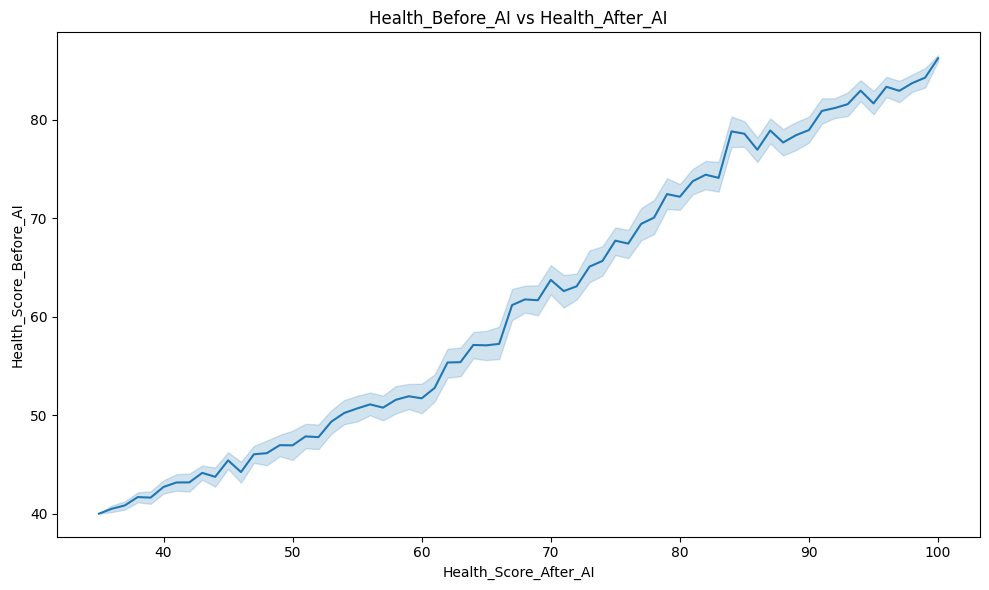

In [71]:
plt.figure(figsize=(10,6))
sns.lineplot(df, y=df['Health_Score_Before_AI'], x=df['Health_Score_After_AI'])
plt.title('Health_Before_AI vs Health_After_AI')
plt.tight_layout()
plt.show()

This lineplot above show that health condition of partients improved after using AI tools 

#### 11. Satisfication_Score vs AI_Usage
Do patients with a 'High' AI Usage level report higher overall satsification scores??

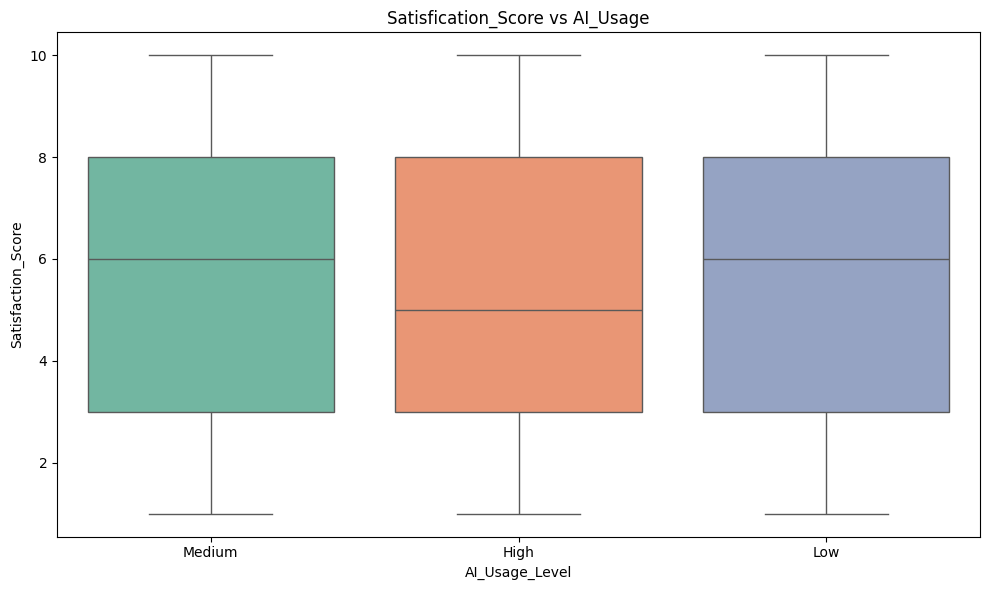

In [72]:
plt.figure(figsize=(10,6))
sns.boxplot(df, x=df['AI_Usage_Level'], y=df['Satisfaction_Score'], palette='Set2')
plt.title('Satisfication_Score vs AI_Usage')
plt.tight_layout()
plt.show()

This boxplot visualize that more patients with high usage level of AI have low satisfication(Because at all three boxplot show that "High" have low median line compareed  to those with highline of median).

#### 12. Improvement vs Health_Score _After_AI by Risk_Category

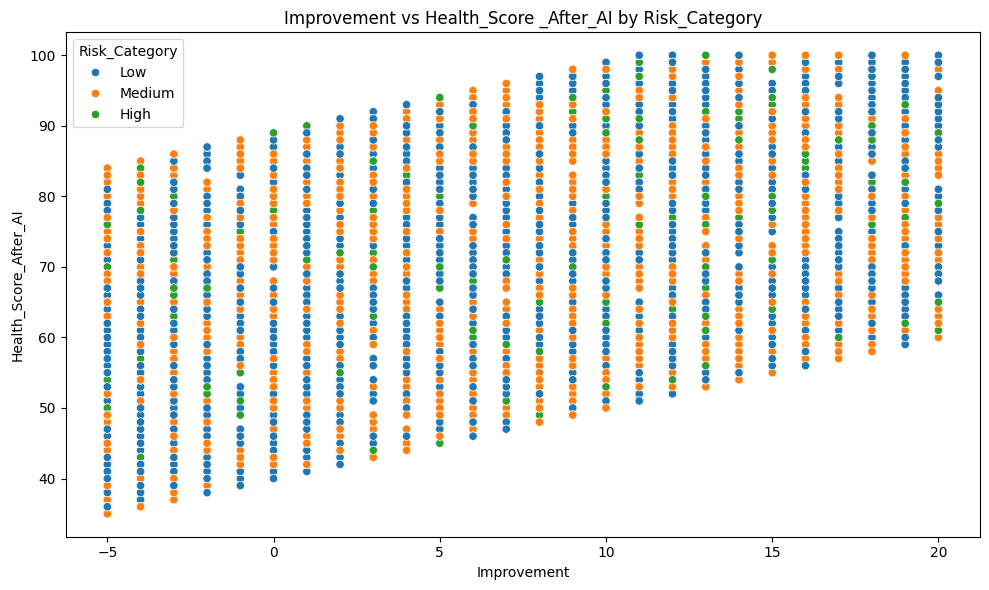

In [73]:
plt.figure(figsize=(10,6))
sns.scatterplot(df, x=df['Improvement'], y=df['Health_Score_After_AI'], hue="Risk_Category")
plt.title('Improvement vs Health_Score _After_AI by Risk_Category')
plt.tight_layout()
plt.show()

#### 14. Correlation heatmap for numeric features 

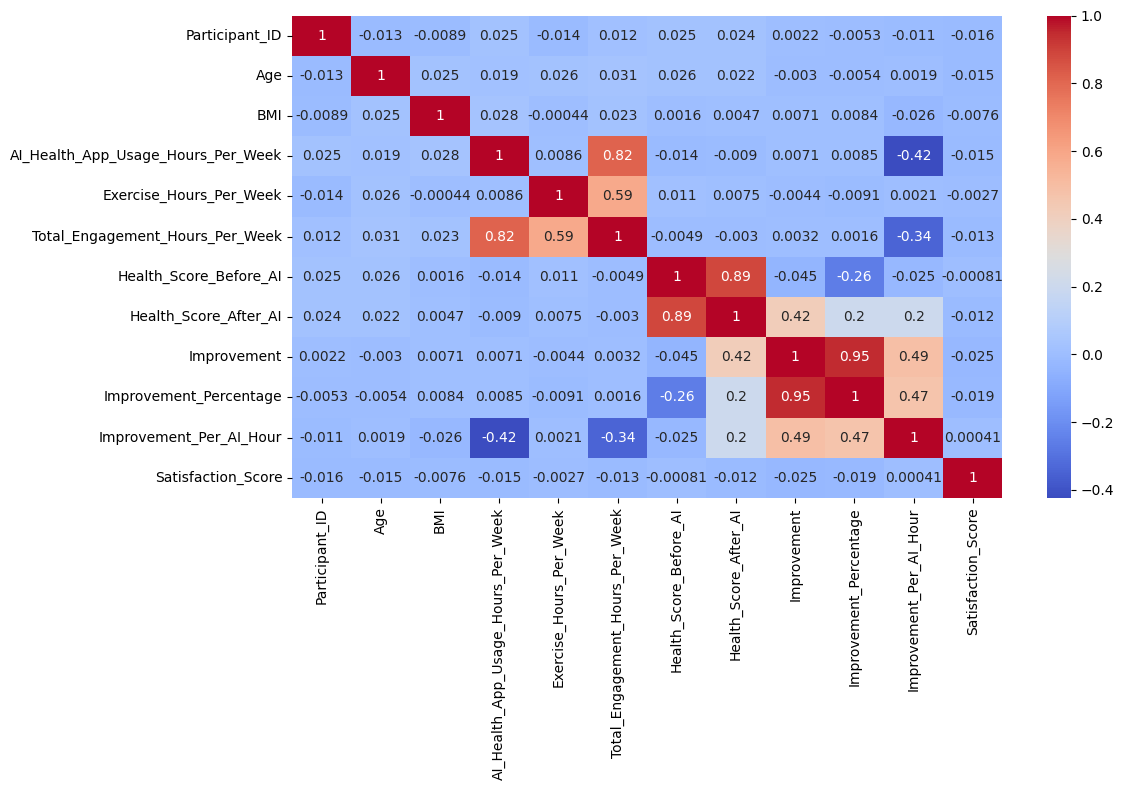

In [74]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()

At heatmap plot show that there are all type of correlation such as positive correlation(imprvement vs Improvement_Percentage), zero correlation(improvement vs particiant ID) and negative correlation(Improvement_Per_Hour vs AI_Health_App_Usage_Hours_Per_Week)

## FEATURES ENGINEERING AND PREDICTIONS

In [75]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

copy the dataframe from df to data

In [76]:
data=df.copy()

#### Remove unnecessary columns and with more outliers

In [77]:
data.drop(columns=['Participant_ID','Improvement_Per_AI_Hour'], inplace=True)

#### Create Variable for our target

In [78]:
target='Improvement'

#### Create X as features for questioning and Y for answer

In [79]:
X = data.drop(columns=[target])
Y = data[target]

In [80]:
num_cols=X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

#### Preprocessing of our Features

In [81]:
num_pro = Pipeline([('imputer',SimpleImputer(strategy='median')),
('scaler',StandardScaler())])
cat_pro = Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
('encoder',OneHotEncoder(handle_unknown='ignore'))])

#### Selection of the Model

In [82]:
model = GradientBoostingRegressor()

#### Connect Pipeline with ColumnTransformer

In [83]:
preprocessor = ColumnTransformer([('numeric',num_pro,num_cols),
('category',cat_pro,cat_cols)])

In [84]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

#### Splitting of Features in train and test

In [85]:
x_train,x_test,y_train,y_test = train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42
)

#### Model Training

In [86]:
pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Age','Age_Group','Gender',...,'Satisfaction_Score','Satisfaction_Level', 'Risk_Category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed th

#### Prediction of the test

In [87]:
pred = pipeline.predict(x_test)

#### Compare Prediiction With the Actual Value

In [88]:
print(y_test)
print(pred)

1501     3
2586    15
2653    -5
1055    17
705     -5
        ..
4711    10
2313    16
3214     1
2732     2
1926     3
Name: Improvement, Length: 1000, dtype: int64
[ 2.79496182e+00  1.48344394e+01 -4.52498705e+00  1.71674410e+01
 -4.71362442e+00  3.20415868e+00  1.40944744e+01  6.35831694e+00
  5.06896763e+00  1.33313291e+01  1.52788624e+01 -1.11590405e+00
 -3.56650850e+00  7.51594038e+00  1.59220391e+01 -3.64317482e+00
 -1.11164129e+00  1.29985105e+01 -5.49606472e-02 -8.97971393e-01
 -1.04103115e+00 -9.17674426e-01  1.90035926e+01  6.90523453e+00
 -2.34743219e+00  8.29854099e+00  1.90177879e+00  4.12802708e+00
  9.59734016e+00  1.89172189e+01  5.28066546e+00  1.42412897e+01
  1.90717770e+01  7.38415700e+00  8.96449732e+00  1.89007185e+01
  1.09654716e+01 -2.70178749e+00 -4.71362442e+00 -4.26734570e+00
 -1.88164420e+00  1.90177879e+00 -3.23045922e+00  3.31070253e+00
 -3.18645822e+00  8.85145126e+00  5.96976288e+00  5.95612218e+00
  5.07000969e+00  1.03978216e+00  1.73517696e+01  1.9

#### Evaluate the Model

In [89]:
score = r2_score(y_test,pred)
print(score)

0.9987772117404828


Create Actual vs Predicted DataFrame

In [90]:
result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': pred
}).sort_values(by='Actual')

Plot graph for Actual vs Predicted

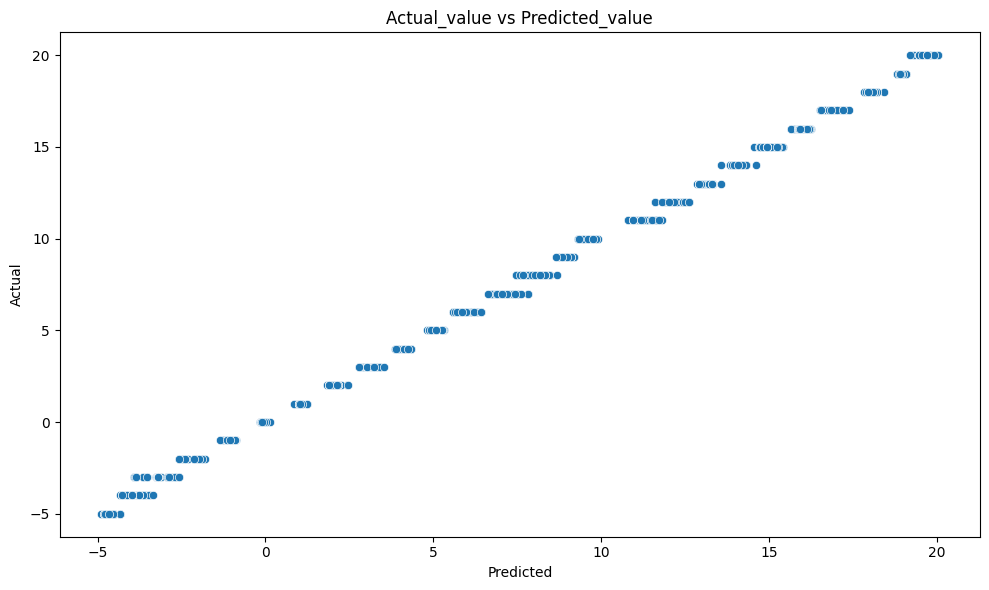

In [91]:
plt.figure(figsize=(10,6))
sns.scatterplot(result, y=result['Actual'], x=result['Predicted'])
plt.title('Actual_value vs Predicted_value')
plt.tight_layout()
plt.show()